In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt



# Load data


In [2]:
# Load data
df = pd.read_csv("sample_data/global_climate_energy_2020_2024.csv")


In [3]:
TARGET_COL = "energy_consumption"
df.head()

,date,country,avg_temperature,humidity,co2_emission,energy_consumption,renewable_share,urban_population,industrial_activity_index,energy_price
0,2020-01-01,Germany,28.29,31.08,212.63,11348.75,14.42,76.39,51.22,83.93
1,2020-01-02,Germany,28.38,37.94,606.05,4166.64,5.63,86.26,78.27,110.40
2,2020-01-03,Germany,28.74,57.67,268.72,4503.80,14.20,75.92,48.96,173.58
3,2020-01-04,Germany,26.66,51.34,167.32,3259.13,13.84,63.15,97.42,89.13
4,2020-01-05,Germany,26.81,65.38,393.89,7023.72,6.93,76.02,81.89,40.60


In [4]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())


Missing values:
date                         0
country                      0
avg_temperature              0
humidity                     0
co2_emission                 0
energy_consumption           0
renewable_share              0
urban_population             0
industrial_activity_index    0
energy_price                 0
dtype: int64

Basic statistics:
       avg_temperature      humidity  co2_emission  energy_consumption  \
count     36540.000000  36540.000000  36540.000000        36540.000000   
mean         13.580868     59.971469    445.820452         7295.904857   
std          10.077249     17.303103    234.360906         3693.928504   
min          -9.600000     30.000000     50.150000         1001.890000   
25%           5.630000     45.010000    248.675000         4184.177500   
50%          13.790000     59.990000    422.655000         6921.620000   
75%          20.840000     74.970000    628.422500        10175.110000   
max          38.710000     90.000000    999.85000

In [6]:
print("\n" + "="*60)
print("PREPROCESSING")
print("="*60)

# Drop rows with missing values
df = df.dropna()
print(f"Dataset shape after removing NaN: {df.shape}")

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from numerical columns
if TARGET_COL in numerical_cols:
    numerical_cols.remove(TARGET_COL)

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# For this dataset: date is date, country is categorical
# Keep date info but encode country
print(f"\nBefore encoding:")
print(f"  - date: {df['date'].dtype}")
print(f"  - country: unique values = {df['country'].nunique()}")



PREPROCESSING
Dataset shape after removing NaN: (36540, 10)

Categorical columns: ['date', 'country']
Numerical columns: ['avg_temperature', 'humidity', 'co2_emission', 'renewable_share', 'urban_population', 'industrial_activity_index', 'energy_price']

Before encoding:
  - date: object
  - country: unique values = 20


In [7]:
# Convert date to datetime and extract features
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

print("\nExtracted date features:")
print(f"  - year, month, day, dayofweek, quarter")

# Drop the original date column (no longer needed)
df = df.drop(columns=['date'])

# One-hot encode 'country' (categorical variable)
df_encoded = pd.get_dummies(df, columns=['country'], drop_first=True)

print(f"\nAfter one-hot encoding country:")
print(f"  - New shape: {df_encoded.shape}")
print(f"  - New columns: {df_encoded.columns.tolist()}")


Extracted date features:
  - year, month, day, dayofweek, quarter

After one-hot encoding country:
  - New shape: (36540, 32)
  - New columns: ['avg_temperature', 'humidity', 'co2_emission', 'energy_consumption', 'renewable_share', 'urban_population', 'industrial_activity_index', 'energy_price', 'year', 'month', 'day', 'dayofweek', 'quarter', 'country_Brazil', 'country_Canada', 'country_China', 'country_France', 'country_Germany', 'country_India', 'country_Indonesia', 'country_Italy', 'country_Japan', 'country_Mexico', 'country_Netherlands', 'country_Norway', 'country_Poland', 'country_South Africa', 'country_Spain', 'country_Sweden', 'country_Turkey', 'country_United Kingdom', 'country_United States']


# Standarization

In [ ]:
# # ============================================
# # CELL 4: STANDARDIZATION
# # ============================================

# print("\n" + "="*60)
# print("STANDARDIZATION")
# print("="*60)

# # Separate features and target
# X = df_encoded.drop(columns=[TARGET_COL])
# y = df_encoded[[TARGET_COL]].copy()

# print(f"Features shape before scaling: {X.shape}")
# print(f"Target shape: {y.shape}")

# # Standardize features
# feature_scaler = StandardScaler()
# X_scaled = feature_scaler.fit_transform(X)
# X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# # Standardize target
# target_scaler = StandardScaler()
# y_scaled = target_scaler.fit_transform(y)
# y_scaled = pd.Series(y_scaled.flatten(), name=TARGET_COL)

# print("\nFeatures standardized (mean ≈ 0, std ≈ 1)")
# print("\nFeature statistics after standardization:")
# print(X_scaled.describe())
# print("\nTarget statistics after standardization:")
# print(y_scaled.describe())



STANDARDIZATION
Features shape before scaling: (36540, 31)
Target shape: (36540, 1)

Features standardized (mean ≈ 0, std ≈ 1)

Feature statistics after standardization:
       avg_temperature      humidity  co2_emission  renewable_share  \
count     3.654000e+04  3.654000e+04  3.654000e+04     3.654000e+04   
mean      2.800168e-17 -2.866284e-16  1.687879e-16     3.437985e-16   
std       1.000014e+00  1.000014e+00  1.000014e+00     1.000014e+00   
min      -2.300349e+00 -1.732168e+00 -1.688319e+00    -2.051477e+00   
25%      -7.890027e-01 -8.646816e-01 -8.412160e-01    -7.355722e-01   
50%       2.075322e-02  1.070990e-03 -9.884656e-02    -4.294118e-02   
75%       7.203585e-01  8.668235e-01  7.791596e-01     7.302937e-01   
max       2.493684e+00  1.735466e+00  2.364034e+00     2.797877e+00   

       urban_population  industrial_activity_index  energy_price  \
count      3.654000e+04               3.654000e+04  3.654000e+04   
mean      -1.071648e-15               5.355322e-16 -1

In [8]:
# ============================================
# CELL 3: SEPARATE FEATURES AND TARGET
# ============================================

print("\n" + "="*80)
print("SEPARATING FEATURES AND TARGET")
print("="*80)

X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[[TARGET_COL]].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"\nOriginal target statistics:")
print(f"  Min: {y.values.min():.4f}")
print(f"  Max: {y.values.max():.4f}")
print(f"  Mean: {y.values.mean():.4f}")
print(f"  Std: {y.values.std():.4f}")


SEPARATING FEATURES AND TARGET
Features shape: (36540, 31)
Target shape: (36540, 1)

Original target statistics:
  Min: 1001.8900
  Max: 15998.0500
  Mean: 7295.9049
  Std: 3693.8780


In [ ]:
# print("data set after preprocessing:")
# print(X_scaled.head())
# print(y_scaled.head())

In [9]:
# ✓ StandardScaler ONLY for features
print("\nStandardizing features (StandardScaler)...")
feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features standardized: mean ≈ 0, std ≈ 1")

# ✓ Min-Max [0, 1] ONLY for target
print("\nNormalizing target to [0, 1] (Min-Max)...")
y_min = y.values.min()
y_max = y.values.max()
y_range = y_max - y_min

y_normalized = (y - y_min) / y_range

print(f"Target normalized:")
print(f"  Min: {y_normalized.values.min():.4f}")
print(f"  Max: {y_normalized.values.max():.4f}")
print(f"  Mean: {y_normalized.values.mean():.4f}")

print(f"\nStored for denormalization:")
print(f"  y_min: {y_min:.4f}")
print(f"  y_max: {y_max:.4f}")
print(f"  y_range: {y_range:.4f}")


Standardizing features (StandardScaler)...
Features standardized: mean ≈ 0, std ≈ 1

Normalizing target to [0, 1] (Min-Max)...
Target normalized:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4197

Stored for denormalization:
  y_min: 1001.8900
  y_max: 15998.0500
  y_range: 14996.1600


In [10]:
print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_normalized, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")


TRAIN-TEST SPLIT
Training set: 21924 samples
Validation set: 7308 samples
Test set: 7308 samples
Number of features: 31


In [11]:
# #split data into train and test sets and validation set
# print("\n" + "="*60)
# print("DATA SPLITTING")
# print("="*60)

# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_scaled, y_scaled, test_size=0.2
# )

# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.25
# )

# print(f"Training set: {X_train.shape[0]} samples")
# print(f"Validation set: {X_val.shape[0]} samples")
# print(f"Test set: {X_test.shape[0]} samples")
# print(f"Number of features: {X_train.shape[1]}")

In [12]:
print("\n" + "="*60)
print("CONVERTING TO PYTORCH TENSORS")
print("="*60)

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(f"X_train tensor shape: {X_train_tensor.shape}")
print(f"y_train tensor shape: {y_train_tensor.shape}")
print(f"X_val tensor shape: {X_val_tensor.shape}")
print(f"X_test tensor shape: {X_test_tensor.shape}")

print("\n" + "="*60)
print("PREPROCESSING COMPLETE!")
print("="*60)
print(f"Ready for model training with {X_train.shape[1]} features")


CONVERTING TO PYTORCH TENSORS
X_train tensor shape: torch.Size([21924, 31])
y_train tensor shape: torch.Size([21924, 1])
X_val tensor shape: torch.Size([7308, 31])
X_test tensor shape: torch.Size([7308, 31])

PREPROCESSING COMPLETE!
Ready for model training with 31 features


In [13]:

class ImprovedEnergyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout=0.4):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim//2),
            nn.LayerNorm(hidden_dim//2),
            nn.GELU(),
            nn.Dropout(dropout/2),

            nn.Linear(hidden_dim//2, 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import copy
# ============================================
# CELL 9: SETUP TRAINING
# ============================================

print("\n" + "="*80)
print("SETTING UP TRAINING")
print("="*80)

batch_size = 64
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Batch size: {batch_size}")

# Create DataLoaders
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)

# Initialize model
model = ImprovedEnergyModel(
    input_dim=X_train.shape[1],
    hidden_dim=512,
    dropout=0.35
).to(device)

# Loss function: HuberLoss (robust to outliers)
criterion = nn.HuberLoss(delta=0.8)

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.4,
    patience=12,
)

# Early stopping
best_val_loss = float('inf')
best_state = None
patience = 50
counter = 0

train_losses = []
val_losses = []

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Loss function: HuberLoss (delta=0.8)")
print(f"Optimizer: AdamW (lr=3e-4)")


# ============================================
# CELL 10: TRAINING LOOP
# ============================================

print("\n" + "="*80)
print("TRAINING")
print("="*80 + "\n")

num_epochs = 400

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    num_batches = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()
        num_batches += 1

    train_loss /= num_batches
    train_losses.append(train_loss)

    # Validation phase
    model.eval()
    val_loss = 0.0
    num_batches = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
            num_batches += 1

    val_loss /= num_batches
    val_losses.append(val_loss)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    # Print progress
    if (epoch + 1) % 20 == 0 or counter == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {lr:.2e} | Patience: [{counter}/{patience}]')

    # Early stopping
    if counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

# Load best model
model.load_state_dict(best_state)
print(f"Best validation loss: {best_val_loss:.5f}")


# ============================================
# CELL 11: EVALUATION & DENORMALIZATION
# ============================================

print("\n" + "="*80)
print("EVALUATION ON TEST SET")
print("="*80)

model.eval()
preds = []
trues = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        preds.extend(pred.cpu().numpy().flatten())
        trues.extend(yb.numpy().flatten())

# Convert to numpy arrays
preds = np.array(preds)
trues = np.array(trues)

# ✓ DENORMALIZE using Min-Max formula (not StandardScaler)
y_pred_normalized = preds
y_true_normalized = trues

y_pred_orig = y_pred_normalized * y_range + y_min
y_true_orig = y_true_normalized * y_range + y_min

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae = mean_absolute_error(y_true_orig, y_pred_orig)
r2 = r2_score(y_true_orig, y_pred_orig)
mse = mean_squared_error(y_true_orig, y_pred_orig)

print(f"\n{'='*80}")
print("FINAL RESULTS (Denormalized to Original Scale)")
print(f"{'='*80}")
print(f"Test MSE:  {mse:,.2f}")
print(f"Test RMSE: {rmse:,.2f}")
print(f"Test MAE:  {mae:,.2f}")
print(f"Test R²:   {r2:.4f}")
print(f"{'='*80}")



SETTING UP TRAINING
Device: cuda
Batch size: 64
Model parameters: 413,185
Loss function: HuberLoss (delta=0.8)
Optimizer: AdamW (lr=3e-4)

TRAINING

Epoch [  1/400] | Train: 0.03544 | Val: 0.02902 | LR: 3.00e-04 | Patience: [0/50]
Epoch [  2/400] | Train: 0.02985 | Val: 0.02831 | LR: 3.00e-04 | Patience: [0/50]
Epoch [  4/400] | Train: 0.02833 | Val: 0.02806 | LR: 3.00e-04 | Patience: [0/50]
Epoch [  5/400] | Train: 0.02794 | Val: 0.02672 | LR: 3.00e-04 | Patience: [0/50]
Epoch [  6/400] | Train: 0.02730 | Val: 0.02633 | LR: 3.00e-04 | Patience: [0/50]
Epoch [  8/400] | Train: 0.02675 | Val: 0.02603 | LR: 3.00e-04 | Patience: [0/50]
Epoch [ 10/400] | Train: 0.02631 | Val: 0.02586 | LR: 3.00e-04 | Patience: [0/50]
Epoch [ 13/400] | Train: 0.02607 | Val: 0.02578 | LR: 3.00e-04 | Patience: [0/50]
Epoch [ 16/400] | Train: 0.02566 | Val: 0.02573 | LR: 3.00e-04 | Patience: [0/50]
Epoch [ 18/400] | Train: 0.02552 | Val: 0.02569 | LR: 3.00e-04 | Patience: [0/50]
Epoch [ 20/400] | Train: 0.025

✓ Saved: actual_vs_predicted_line.png


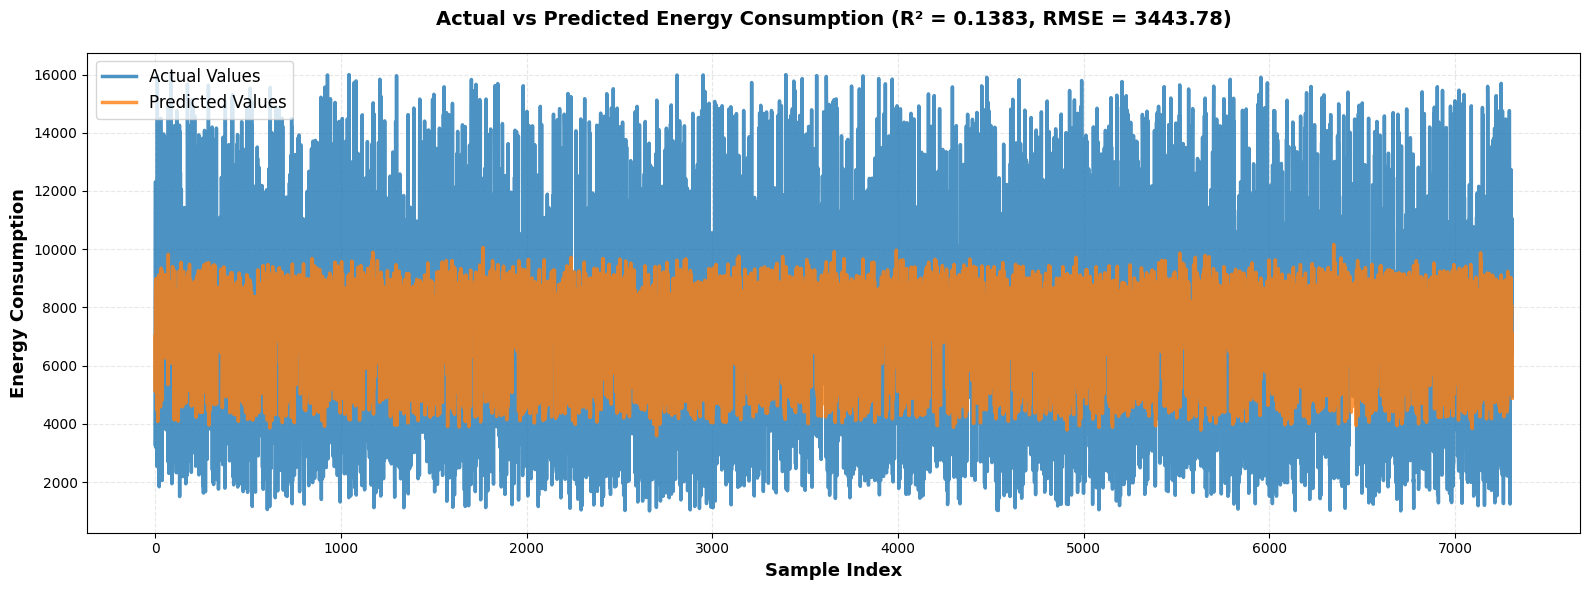

✓ Saved: actual_vs_predicted_error_band.png


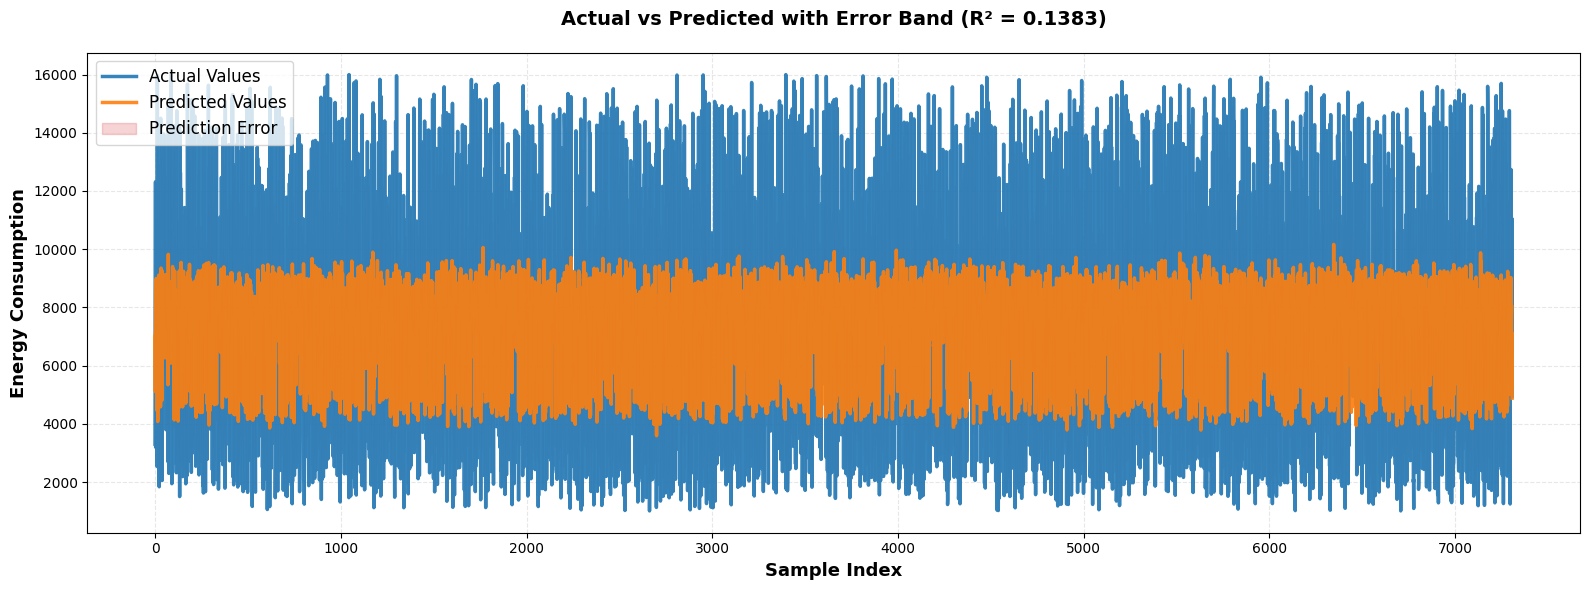

✓ Saved: actual_vs_predicted_sorted.png


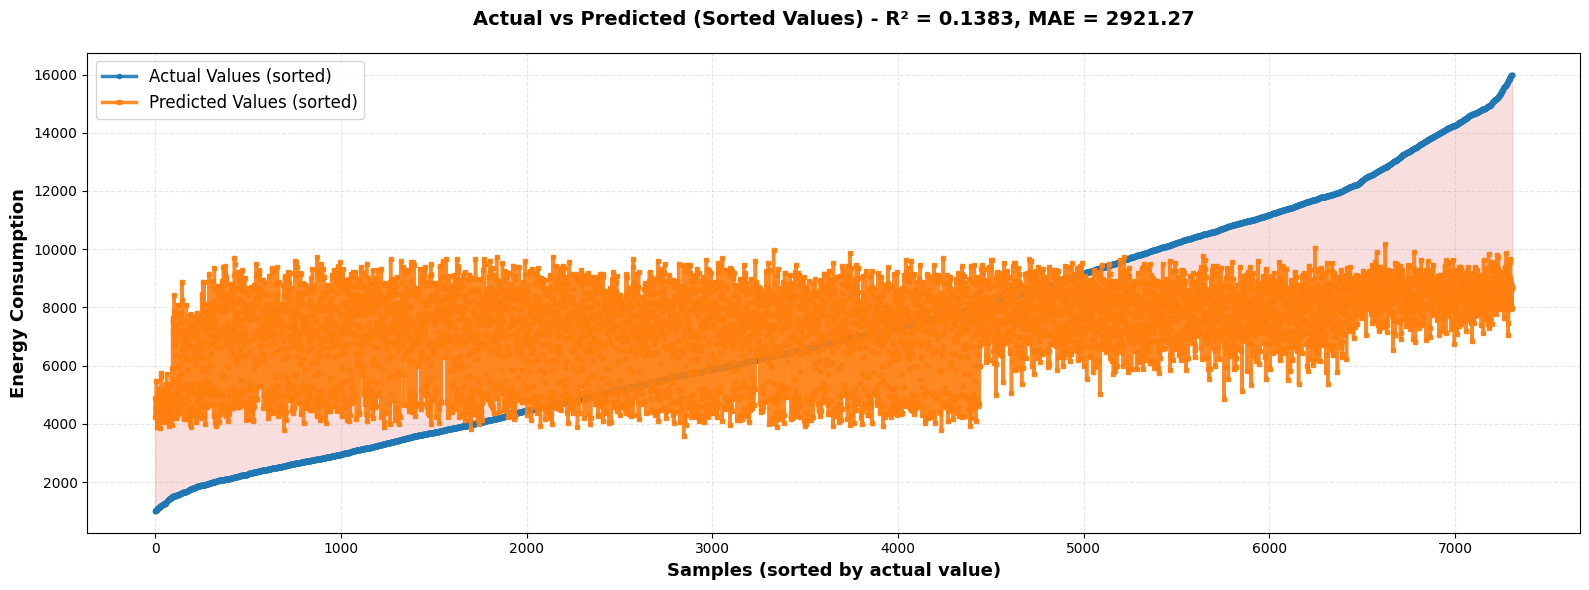

✓ Saved: actual_vs_predicted_dual_axis.png


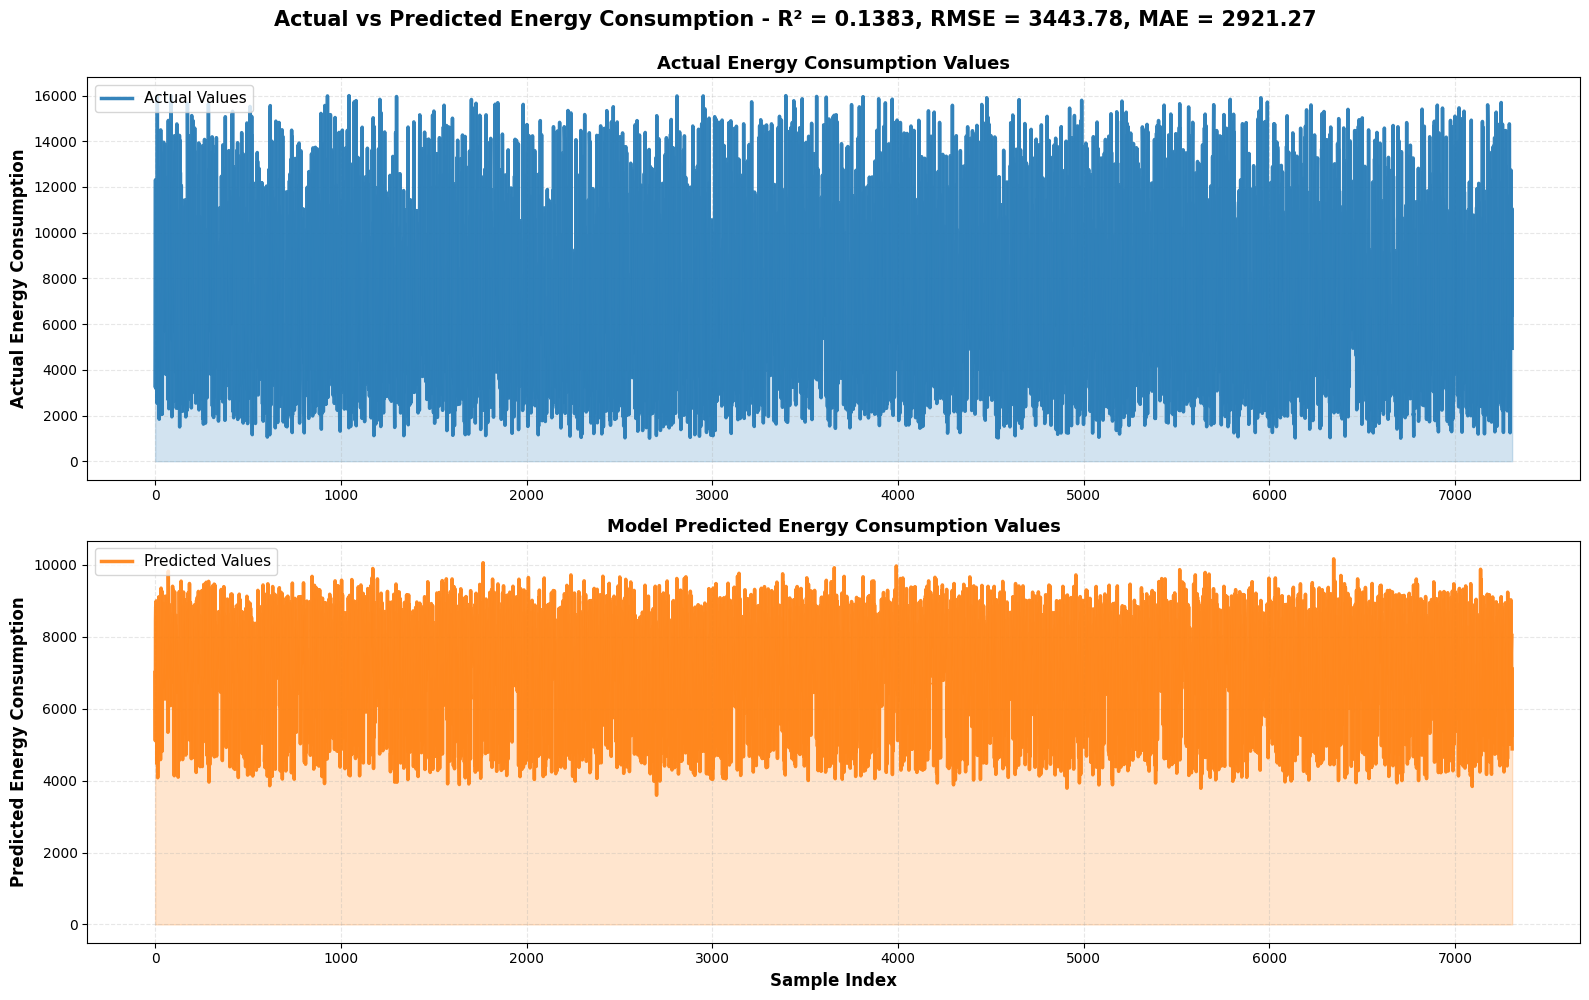

✓ Saved: actual_vs_predicted_moving_avg.png


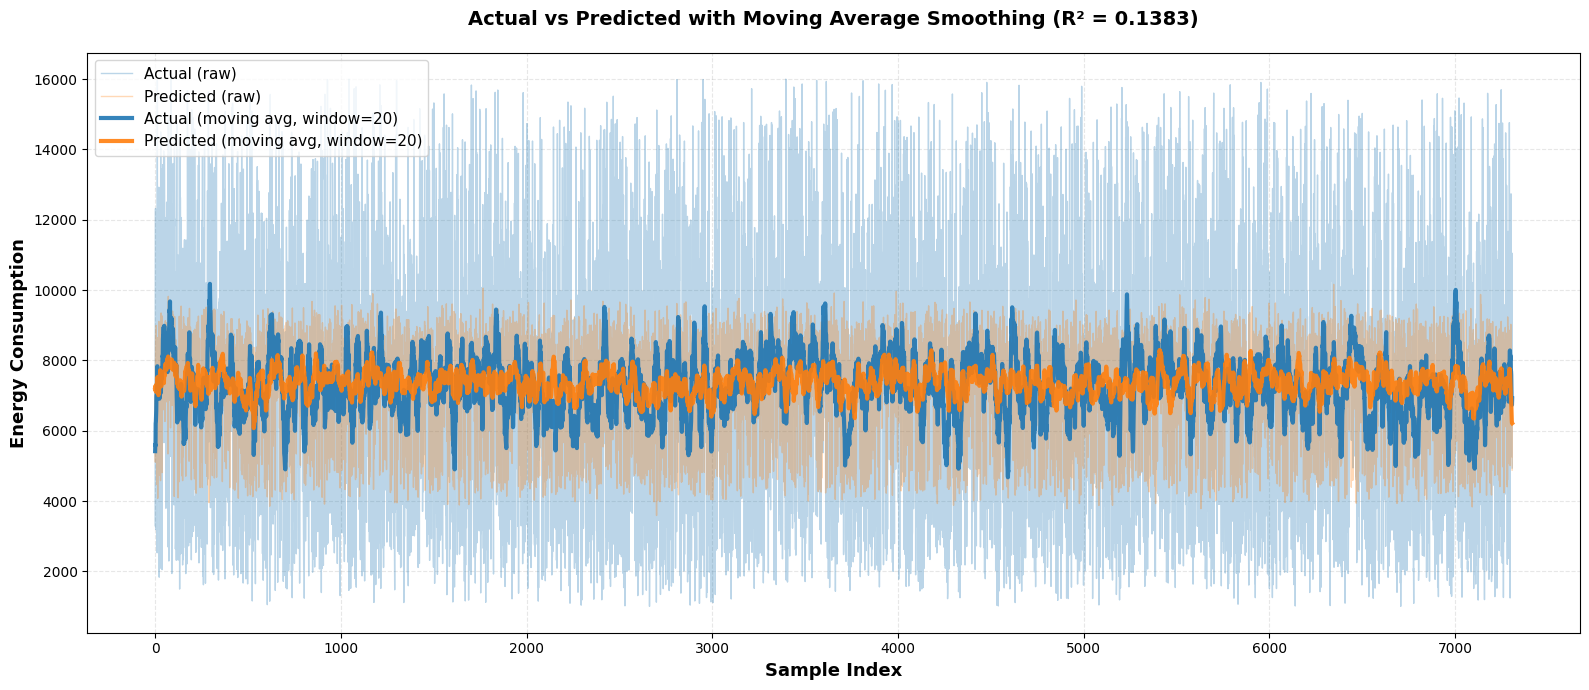

✓ Saved: actual_vs_predicted_comprehensive.png (BEST FOR PAPER)


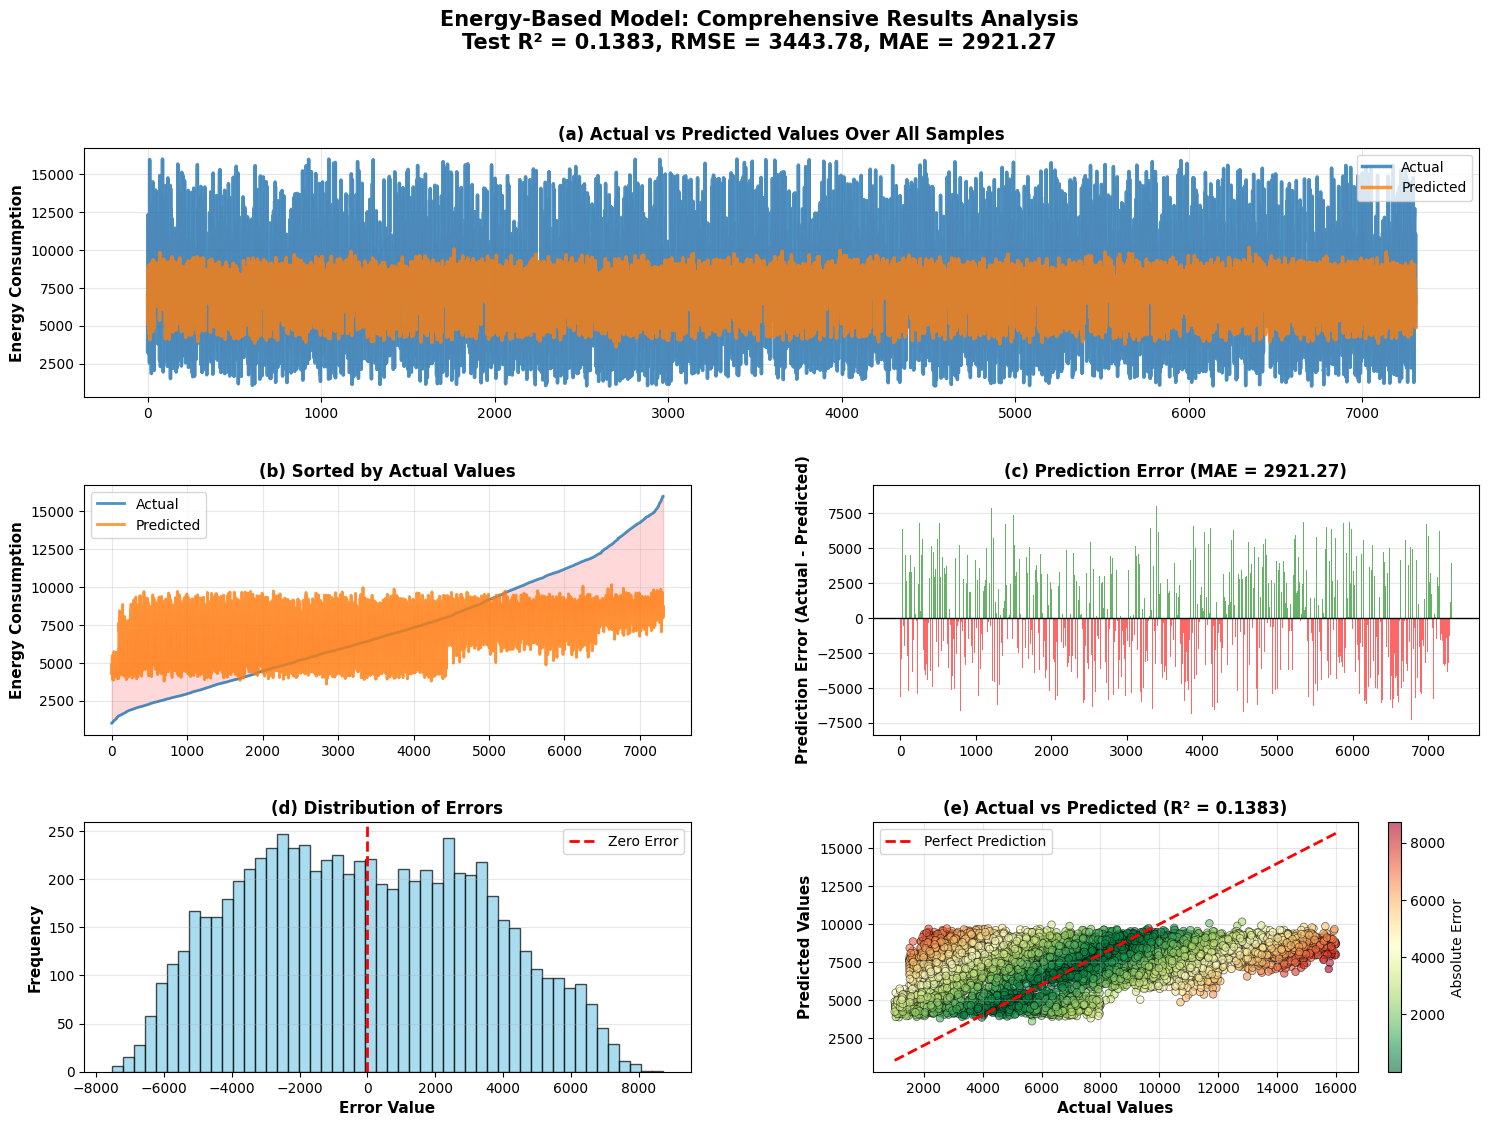

In [15]:
# ============================================
# VISUALIZATION: ACTUAL vs PREDICTED VALUES
# SUITABLE FOR ACADEMIC PAPER
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Assuming you have: y_true_orig, y_pred_orig, r2, mae, rmse

# ============================================
# OPTION 1: LINE PLOT (Best for Sequential Data)
# ============================================

plt.figure(figsize=(16, 6))

# Create x-axis (sample index)
x = np.arange(len(y_true_orig))

# Plot both lines
plt.plot(x, y_true_orig, label='Actual Values', linewidth=2.5, color='#1f77b4', alpha=0.8)
plt.plot(x, y_pred_orig, label='Predicted Values', linewidth=2.5, color='#ff7f0e', alpha=0.8)

plt.xlabel('Sample Index', fontsize=13, fontweight='bold')
plt.ylabel('Energy Consumption', fontsize=13, fontweight='bold')
plt.title(f'Actual vs Predicted Energy Consumption (R² = {r2:.4f}, RMSE = {rmse:.2f})',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('actual_vs_predicted_line.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_line.png")
plt.show()


# ============================================
# OPTION 2: SHADED ERROR BAND
# ============================================

plt.figure(figsize=(16, 6))

x = np.arange(len(y_true_orig))

# Calculate error (difference between actual and predicted)
error = y_true_orig - y_pred_orig

# Plot actual values
plt.plot(x, y_true_orig, label='Actual Values', linewidth=2.5, color='#1f77b4', alpha=0.9)

# Plot predicted values
plt.plot(x, y_pred_orig, label='Predicted Values', linewidth=2.5, color='#ff7f0e', alpha=0.9)

# Shade the error region between actual and predicted
plt.fill_between(x, y_true_orig, y_pred_orig, alpha=0.2, color='#d62728', label='Prediction Error')

plt.xlabel('Sample Index', fontsize=13, fontweight='bold')
plt.ylabel('Energy Consumption', fontsize=13, fontweight='bold')
plt.title(f'Actual vs Predicted with Error Band (R² = {r2:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('actual_vs_predicted_error_band.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_error_band.png")
plt.show()


# ============================================
# OPTION 3: SORTED VALUES (Shows Model Performance Better)
# ============================================

# Sort by actual values to see how well model follows the trend
sorted_indices = np.argsort(y_true_orig)
y_true_sorted = y_true_orig[sorted_indices]
y_pred_sorted = y_pred_orig[sorted_indices]

plt.figure(figsize=(16, 6))

x = np.arange(len(y_true_sorted))

plt.plot(x, y_true_sorted, label='Actual Values (sorted)', linewidth=2.5, color='#1f77b4', alpha=0.9, marker='o', markersize=3)
plt.plot(x, y_pred_sorted, label='Predicted Values (sorted)', linewidth=2.5, color='#ff7f0e', alpha=0.9, marker='s', markersize=3)

plt.fill_between(x, y_true_sorted, y_pred_sorted, alpha=0.15, color='#d62728')

plt.xlabel('Samples (sorted by actual value)', fontsize=13, fontweight='bold')
plt.ylabel('Energy Consumption', fontsize=13, fontweight='bold')
plt.title(f'Actual vs Predicted (Sorted Values) - R² = {r2:.4f}, MAE = {mae:.2f}',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('actual_vs_predicted_sorted.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_sorted.png")
plt.show()


# ============================================
# OPTION 4: DUAL AXIS (Shows Both Sequences Clearly)
# ============================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

x = np.arange(len(y_true_orig))

# Top plot: Actual values
ax1.plot(x, y_true_orig, label='Actual Values', linewidth=2.5, color='#1f77b4', alpha=0.9)
ax1.fill_between(x, y_true_orig, alpha=0.2, color='#1f77b4')
ax1.set_ylabel('Actual Energy Consumption', fontsize=12, fontweight='bold')
ax1.set_title('Actual Energy Consumption Values', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='upper left')

# Bottom plot: Predicted values
ax2.plot(x, y_pred_orig, label='Predicted Values', linewidth=2.5, color='#ff7f0e', alpha=0.9)
ax2.fill_between(x, y_pred_orig, alpha=0.2, color='#ff7f0e')
ax2.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Predicted Energy Consumption', fontsize=12, fontweight='bold')
ax2.set_title('Model Predicted Energy Consumption Values', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=11, loc='upper left')

fig.suptitle(f'Actual vs Predicted Energy Consumption - R² = {r2:.4f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}',
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout()
plt.savefig('actual_vs_predicted_dual_axis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_dual_axis.png")
plt.show()


# ============================================
# OPTION 5: OVERLAID WITH MOVING AVERAGE
# ============================================

from scipy.ndimage import uniform_filter1d

# Calculate moving average for smoothing
window = 20  # 20-sample window
actual_smooth = uniform_filter1d(y_true_orig, size=window, mode='nearest')
pred_smooth = uniform_filter1d(y_pred_orig, size=window, mode='nearest')

plt.figure(figsize=(16, 7))

x = np.arange(len(y_true_orig))

# Plot raw values (transparent)
plt.plot(x, y_true_orig, linewidth=1, color='#1f77b4', alpha=0.3, label='Actual (raw)')
plt.plot(x, y_pred_orig, linewidth=1, color='#ff7f0e', alpha=0.3, label='Predicted (raw)')

# Plot smoothed values (bold)
plt.plot(x, actual_smooth, linewidth=3, color='#1f77b4', alpha=0.9, label=f'Actual (moving avg, window={window})')
plt.plot(x, pred_smooth, linewidth=3, color='#ff7f0e', alpha=0.9, label=f'Predicted (moving avg, window={window})')

plt.xlabel('Sample Index', fontsize=13, fontweight='bold')
plt.ylabel('Energy Consumption', fontsize=13, fontweight='bold')
plt.title(f'Actual vs Predicted with Moving Average Smoothing (R² = {r2:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('actual_vs_predicted_moving_avg.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_moving_avg.png")
plt.show()


# ============================================
# OPTION 6: COMPREHENSIVE MULTI-PANEL
# (Best for Paper - Shows Everything)
# ============================================

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Panel 1: Line plot
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(y_true_orig))
ax1.plot(x, y_true_orig, label='Actual', linewidth=2.5, color='#1f77b4', alpha=0.8)
ax1.plot(x, y_pred_orig, label='Predicted', linewidth=2.5, color='#ff7f0e', alpha=0.8)
ax1.fill_between(x, y_true_orig, y_pred_orig, alpha=0.15, color='red')
ax1.set_ylabel('Energy Consumption', fontsize=11, fontweight='bold')
ax1.set_title('(a) Actual vs Predicted Values Over All Samples', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel 2: Sorted values
ax2 = fig.add_subplot(gs[1, 0])
sorted_idx = np.argsort(y_true_orig)
y_true_s = y_true_orig[sorted_idx]
y_pred_s = y_pred_orig[sorted_idx]
ax2.plot(range(len(y_true_s)), y_true_s, label='Actual', linewidth=2, color='#1f77b4', alpha=0.8)
ax2.plot(range(len(y_pred_s)), y_pred_s, label='Predicted', linewidth=2, color='#ff7f0e', alpha=0.8)
ax2.fill_between(range(len(y_true_s)), y_true_s, y_pred_s, alpha=0.15, color='red')
ax2.set_ylabel('Energy Consumption', fontsize=11, fontweight='bold')
ax2.set_title('(b) Sorted by Actual Values', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Panel 3: Prediction error
ax3 = fig.add_subplot(gs[1, 1])
error = y_true_orig - y_pred_orig
ax3.bar(range(len(error)), error, color=['green' if e > 0 else 'red' for e in error], alpha=0.6, width=1)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('Prediction Error (Actual - Predicted)', fontsize=11, fontweight='bold')
ax3.set_title(f'(c) Prediction Error (MAE = {mae:.2f})', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Error distribution
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(error, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax4.set_xlabel('Error Value', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('(d) Distribution of Errors', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Panel 5: Scatter (Actual vs Predicted)
ax5 = fig.add_subplot(gs[2, 1])
scatter = ax5.scatter(y_true_orig, y_pred_orig, c=np.abs(error), cmap='RdYlGn_r',
                     alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
ax5.plot([y_true_orig.min(), y_true_orig.max()],
         [y_true_orig.min(), y_true_orig.max()],
         'r--', lw=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Values', fontsize=11, fontweight='bold')
ax5.set_ylabel('Predicted Values', fontsize=11, fontweight='bold')
ax5.set_title(f'(e) Actual vs Predicted (R² = {r2:.4f})', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax5)
cbar.set_label('Absolute Error', fontsize=10)

# Main title
fig.suptitle(f'Energy-Based Model: Comprehensive Results Analysis\nTest R² = {r2:.4f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}',
             fontsize=15, fontweight='bold', y=0.995)

plt.savefig('actual_vs_predicted_comprehensive.png', dpi=300, bbox_inches='tight')
print("✓ Saved: actual_vs_predicted_comprehensive.png (BEST FOR PAPER)")
plt.show()
